In [71]:
import pytensor
# Tell PyTensor to use a more robust (but slower) backend that avoids C compilation issues.
# Place this in the first cell of your notebook.
pytensor.config.optimizer = 'fast_compile'

import pandas as pd
import numpy as np
import pymc as pm
import scipy.stats as stats
import arviz as az

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, minmax_scale

from gurobipy import *
import pytensor.tensor as pt

import joblib


## Get player details


In [72]:
players_preds = pd.read_csv('./../FPL predictors/with new features/models/preds/players_preds_36.csv', index_col=0)
fpl_teams_ids = pd.read_csv('../FPL predictors/with new features/data/fpl_names_24_25.csv')

players_preds = players_preds.rename(columns={'FPL_Name': 'fpl_name', 'Understat_Name': 'understat_name'})
# Add fpl_id to player_preds
players_preds = players_preds.merge(fpl_teams_ids, left_on='fpl_name', right_on='FPL_Name', how='left')
players_preds.dropna(subset=['FPL_ID'], inplace=True)

players_preds = players_preds.drop(['event', 'understat_name', 'fpl_name', 'FPL_ID','FPL_Name', 'team', 'xG_preds', 'xA_preds', 'cs_preds', 'y_preds', 'saves_preds', 'xgc_preds', 'h_team', 'a_team','was_home', 'assists_x'], axis=1)
player_cols = players_preds.columns.tolist()

In [73]:
data_cols_all = ['clean_sheets',  'creativity', 'ict_index',  'influence',  'selected',  'threat',  'transfers_balance', 'transfers_in',  'transfers_out',  'value',
                 'team_h_difficulty',  'team_a_difficulty', 'ownership_change',  'percenatge_net_transfers', 'whh',  'whd',  'wha', 'xP','ownership_percent',

            'clean_sheets_1',  'expected_assists_1',  'expected_goal_involvements_1',
            'expected_goals_1',  'expected_goals_conceded_1',  'goals_conceded_1',  'goals_scored_1',  'ict_index_1',  'influence_1',
            'creativity_1',  'threat_1',  'minutes_1',  'own_goals_1',  'penalties_missed_1',  'penalties_saved_1',  'red_cards_1',
            'yellow_cards_1',  'saves_1',  'starts_1',  'team_a_score_1',  'team_h_score_1',  'total_points_1',  'goals_1',  'shots_1',
            'xG_1',  'xA_1',  'assists_x_1',  'key_passes_1',  'npg_1',  'npxG_1',  'xGChain_1',  'xGBuildup_1',  'xP_1',

            'clean_sheets_3',  'expected_assists_3',  'expected_goal_involvements_3',  'expected_goals_3',  'expected_goals_conceded_3',
            'goals_conceded_3',  'goals_scored_3',  'ict_index_3',  'influence_3',  'creativity_3',  'threat_3',  'minutes_3',  'own_goals_3',
            'penalties_missed_3',  'penalties_saved_3',  'red_cards_3',  'yellow_cards_3',  'saves_3',  'starts_3',  'team_a_score_3',
            'team_h_score_3',  'total_points_3',  'goals_3',  'shots_3',  'xG_3',  'xA_3',  'assists_x_3', 'key_passes_3',
            'npg_3',  'npxG_3',  'xGChain_3',  'xGBuildup_3',  'xP_3',

            'clean_sheets_5',  'expected_assists_5',  'expected_goal_involvements_5',  'expected_goals_5',  'expected_goals_conceded_5',  'goals_conceded_5',
            'goals_scored_5',  'ict_index_5',  'influence_5',  'creativity_5',  'threat_5',  'minutes_5',  'own_goals_5',  'penalties_missed_5',  'penalties_saved_5',
            'red_cards_5',  'yellow_cards_5',  'saves_5',  'starts_5',  'team_a_score_5',  'team_h_score_5',  'total_points_5',  'goals_5',  'shots_5',  'xG_5',  'xA_5',
            'assists_x_5', 'key_passes_5',  'npg_5',  'npxG_5',  'xGChain_5',  'xGBuildup_5',  'xP_5', 'xP_cost'
        ]

data_cols_gk = [
                'clean_sheets', 'creativity', 'ict_index', 'influence', 'selected', 'threat', 'transfers_balance', 'transfers_in', 'transfers_out', 'value',
                'team_h_difficulty', 'team_a_difficulty', 'ownership_change', 'percenatge_net_transfers', 'whh',  'whd',  'wha', 'xP','ownership_percent',

                'clean_sheets_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'ict_index_1', 'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1',
                'penalties_saved_1', 'red_cards_1', 'yellow_cards_1', 'saves_1', 'starts_1', 'team_a_score_1', 'team_h_score_1', 'total_points_1',  'goals_1', 'xG_1',
                'key_passes_1', 'xGChain_1', 'xGBuildup_1', 'xP_1',

                'clean_sheets_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'ict_index_3', 'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3',
                'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3', 'team_a_score_3', 'team_h_score_3', 'total_points_3', 'goals_3', 'shots_3', 'key_passes_3',
                'xGChain_3', 'xGBuildup_3', 'xP_3',

                'clean_sheets_5', 'expected_goals_conceded_5',  'goals_conceded_5', 'ict_index_5',  'influence_5',  'creativity_5',  'threat_5',  'minutes_5',  'own_goals_5',
                'penalties_saved_5', 'red_cards_5',  'yellow_cards_5',  'saves_5',  'starts_5',  'team_a_score_5',  'team_h_score_5', 'total_points_5',  'goals_5',  'shots_5',
                'key_passes_5', 'xGChain_5',  'xGBuildup_5', 'xP_5', 'xP_cost'
                ]

data_cols = [
                'clean_sheets', 'creativity', 'ict_index', 'influence', 'selected', 'threat', 'transfers_balance', 'transfers_in', 'transfers_out', 'value',
                'team_h_difficulty',  'team_a_difficulty', 'ownership_change', 'percenatge_net_transfers', 'whh', 'whd', 'wha', 'xP', 'ownership_percent',

                'clean_sheets_1', 'expected_assists_1', 'expected_goal_involvements_1', 'expected_goals_1', 'expected_goals_conceded_1', 'goals_conceded_1',
                'goals_scored_1', 'ict_index_1', 'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'red_cards_1', 'yellow_cards_1', 'saves_1', 'starts_1',
                'team_a_score_1', 'team_h_score_1', 'total_points_1', 'goals_1', 'shots_1', 'xG_1', 'xA_1', 'assists_x_1', 'key_passes_1', 'npg_1', 'npxG_1',
                'xGChain_1', 'xGBuildup_1', 'xP_1',

                'clean_sheets_3', 'expected_assists_3', 'expected_goal_involvements_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3',
                'goals_scored_3', 'ict_index_3', 'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
                'team_a_score_3', 'team_h_score_3', 'total_points_3', 'goals_3', 'shots_3', 'xG_3', 'xA_3', 'assists_x_3', 'key_passes_3', 'npg_3', 'npxG_3',
                'xGChain_3', 'xGBuildup_3', 'xP_3',

                'clean_sheets_5', 'expected_assists_5', 'expected_goal_involvements_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5',
                'goals_scored_5', 'ict_index_5', 'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
                'team_a_score_5', 'team_h_score_5', 'total_points_5', 'goals_5', 'shots_5', 'xG_5', 'xA_5', 'assists_x_5', 'key_passes_5', 'npg_5', 'npxG_5',
                'xGChain_5', 'xGBuildup_5', 'xP_5', 'xP_cost'
        ]


In [74]:
gw=35
data_23_24 = pd.read_csv('../FPL predictors/Fantasy Go/fantasyGo_FPL.csv') #.dropna()

data_23_24['xP_cost'] = round(data_23_24['xP']/data_23_24['value'], 2)

data_tar = data_23_24[data_23_24['event']==gw]
data = data_23_24[data_23_24['event'] < gw]
data_24_25_test = data_23_24[data_23_24['event'] > gw]



joblib.dump(data_cols, './data_cols')

# data_ = data[data_cols]
gk_data = data[data['position'] == 'GK'][data_cols_gk]
def_data = data[data['position'] == 'DEF'][data_cols]
mid_data = data[data['position'] == 'MID'][data_cols]
fwd_data = data[data['position'] == 'FWD'][data_cols]

gk_data = gk_data.select_dtypes(include=[np.number])
gk_data = gk_data.dropna()
gk_data = pd.DataFrame(minmax_scale(gk_data), columns=gk_data.columns, index=gk_data.index)

def_data = def_data.select_dtypes(include=[np.number])
def_data = def_data.dropna()
def_data = pd.DataFrame(minmax_scale(def_data), columns=def_data.columns, index=def_data.index)

mid_data = mid_data.select_dtypes(include=[np.number])
mid_data = mid_data.dropna()
mid_data = pd.DataFrame(minmax_scale(mid_data), columns=mid_data.columns, index=mid_data.index)

fwd_data = fwd_data.select_dtypes(include=[np.number])
fwd_data = fwd_data.dropna()
fwd_data = pd.DataFrame(minmax_scale(fwd_data), columns=fwd_data.columns, index=fwd_data.index)

# Selection percentages
gk_select_by = gk_data['ownership_percent']
def_select_by = def_data['ownership_percent']
mid_select_by = mid_data['ownership_percent']
fwd_select_by = fwd_data['ownership_percent']

# Normalise the select_percts to get the working probs
gk_probs = gk_select_by/np.sum(gk_select_by)
def_probs = def_select_by/np.sum(def_select_by)
mid_probs = mid_select_by/np.sum(mid_select_by)
fwd_probs = fwd_select_by/np.sum(fwd_select_by)

# 1. Define a small constant (epsilon) to replace the zeros
epsilon = 1e-9 # A very small number

# 2. Replace all zeros with this small number
gk_probs[gk_probs == 0] = epsilon
def_probs[def_probs == 0] = epsilon
mid_probs[mid_probs == 0] = epsilon
fwd_probs[fwd_probs == 0] = epsilon



gk_data = gk_data.drop(columns='ownership_percent')
def_data = def_data.drop(columns='ownership_percent')
mid_data = mid_data.drop(columns='ownership_percent')
fwd_data = fwd_data.drop(columns='ownership_percent')

In [75]:

X_def = def_data  # shape: (n_defenders, n_features)

# 1. Standardize (PCA works best on standardized data)
scaler_gk = StandardScaler(with_mean=True, with_std=True)
scaler_def = StandardScaler(with_mean=True, with_std=True)
scaler_mid = StandardScaler(with_mean=True, with_std=True)
scaler_fwd = StandardScaler(with_mean=True, with_std=True)

print(gk_data.shape)
X_gk = scaler_gk.fit_transform(gk_data.values)
X_def = scaler_def.fit_transform(def_data.values)
X_mid = scaler_mid.fit_transform(mid_data.values)
X_fwd = scaler_fwd.fit_transform(fwd_data.values)

# save standardscaler model
joblib.dump(scaler_gk, "scaler_gk.pkl")
joblib.dump(scaler_def, "scaler_def.pkl")
joblib.dump(scaler_mid, "scaler_mid.pkl")
joblib.dump(scaler_fwd, "scaler_fwd.pkl")


# 2. Choose # of components or variance threshold
pca_gk = PCA(n_components=0.95)  # 0.95 = keep enough PCs to explain 95% of variance
pca_def = PCA(n_components=0.95)
pca_mid = PCA(n_components=0.95)
pca_fwd = PCA(n_components=0.95)

# 3. Fit PCA and transform
X_gk_pca = pd.DataFrame(pca_gk.fit_transform(X_gk))
X_def_pca = pd.DataFrame(pca_def.fit_transform(X_def))
X_mid_pca = pd.DataFrame(pca_mid.fit_transform(X_mid))
X_fwd_pca = pd.DataFrame(pca_fwd.fit_transform(X_fwd))

# save pca mode;
joblib.dump(pca_gk, "pca_gk.pkl")
joblib.dump(pca_def, "pca_def.pkl")
joblib.dump(pca_mid, "pca_mid.pkl")
joblib.dump(pca_fwd, "pca_fwd.pkl")

print("Original shape:", X_gk.shape, X_def.shape, X_mid.shape, X_fwd.shape)
print("Reduced shape:", X_gk_pca.shape, X_def_pca.shape, X_mid_pca.shape, X_fwd_pca.shape)

(633, 87)
Original shape: (633, 87) (2983, 109) (4166, 109) (1193, 109)
Reduced shape: (633, 38) (2983, 43) (4166, 41) (1193, 40)


In [34]:
import pymc as pm
import numpy as np
import pandas as pd

def fit_dirichlet_regression(X, P_observed):
    """
    Fits a Bayesian Dirichlet regression model using PyMC to estimate beta coefficients.


    Args:
        X (np.ndarray): The feature matrix for a specific position (e.g., GKs).
                        Shape should be (num_players, num_features).
        P_observed (np.ndarray): The observed historical ownership proportions for that position.
                                 Shape should be (num_players,). Must sum to 1.

    Returns:
        pm.backends.base.MultiTrace: The results of the MCMC simulation, containing posterior samples for beta.
    """
    n_players, n_features = X.shape

    with pm.Model() as dirichlet_model:
        # 1. Define priors for our beta coefficients. We'll use a flat (uninformative) prior as mentioned.
        # [span_0](start_span)This corresponds to p(beta) in equation (6)[span_0](end_span).
        betas = pm.Normal("betas", mu=0, sigma=10, shape=(n_features,))

        # 2. Calculate alpha based on the linear model: alpha = exp(X * beta)
        # [span_1](start_span)This is equation (4) in the paper[span_1](end_span).
        alpha = pm.math.exp(pm.math.dot(X, betas))

        # 3. Define the likelihood of our observed data P_observed
        # The observed ownership proportions are assumed to follow a Dirichlet distribution
        # parameterized by alpha. [span_2](start_span)[span_3](start_span)This is the core of the regression[span_2](end_span)[span_3](end_span).
        p_obs = pm.Dirichlet('p_obs', a=alpha, observed=P_observed)

        # 4. Run the MCMC sampler to get the posterior distribution of beta
        print("Fitting Dirichlet regression model with PyMC...")
        trace = pm.sample(3000, tune=1000, chains=4, cores=1)
        print("✅ Model fitting complete.")

    return trace




In [35]:
# Fit the model to get beta estimates
trace_gk = fit_dirichlet_regression(X_gk_pca, gk_probs)

# Extract the mean of the beta posterior samples to use in Algorithm 1
beta_estimates_gk = trace_gk.posterior['betas'].mean(axis=(0,1)).values

Fitting Dirichlet regression model with PyMC...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [betas]


Output()

Output()

Output()

Output()

Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 76 seconds.


✅ Model fitting complete.


In [81]:
joblib.dump(trace_gk, './trace_gk')

['./trace_gk']

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
betas[0],-0.05,0.00,-0.06,-0.04,0.0,0.0,22637.84,9893.37,1.0
betas[1],0.02,0.00,0.01,0.03,0.0,0.0,22380.55,9181.71,1.0
betas[2],0.10,0.01,0.09,0.11,0.0,0.0,25187.64,8707.52,1.0
betas[3],-0.04,0.01,-0.05,-0.02,0.0,0.0,20631.31,9062.78,1.0
betas[4],0.06,0.01,0.05,0.08,0.0,0.0,23430.19,8954.95,1.0
betas[5],-0.05,0.01,-0.07,-0.04,0.0,0.0,22681.49,8710.23,1.0
betas[6],0.05,0.01,0.03,0.06,0.0,0.0,25960.52,9533.10,1.0
betas[7],-0.02,0.01,-0.03,0.00,0.0,0.0,25522.44,9457.57,1.0
betas[8],0.00,0.01,-0.01,0.02,0.0,0.0,27823.56,9515.62,1.0
betas[9],0.15,0.01,0.13,0.17,0.0,0.0,22524.41,9225.85,1.0


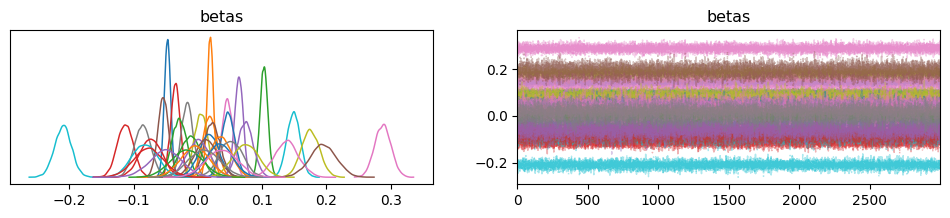

In [36]:
# trace_gk
az.plot_trace(trace_gk, combined=True)

# Summary with R-hat, ESS, mean, sd, etc.
summary = az.summary(trace_gk, var_names=["betas"], round_to=2)
summary

Fitting Dirichlet regression model with PyMC...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [betas]


Output()

Output()

Output()

Output()

Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 205 seconds.


✅ Model fitting complete.


array([[<Axes: title={'center': 'betas'}>,
        <Axes: title={'center': 'betas'}>]], dtype=object)

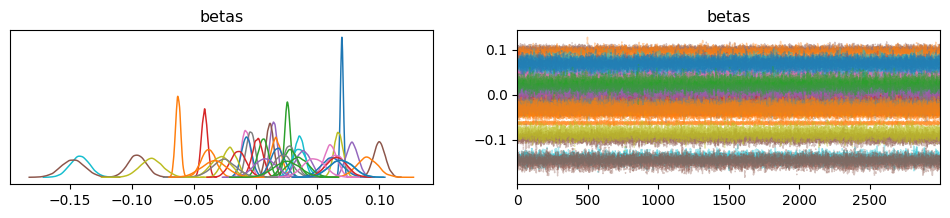

In [37]:
# Fit the model to get beta estimates
trace_def = fit_dirichlet_regression(X_def_pca, def_probs)

# Extract the mean of the beta posterior samples to use in Algorithm 1
beta_estimates_def = trace_def.posterior['betas'].mean(axis=(0,1)).values

trace_def
az.plot_trace(trace_def, combined=True)

In [50]:
X_mid_pca.shape, mid_probs.shape

((4166, 41), (4166,))

Fitting Dirichlet regression model with PyMC...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [betas]


Output()

Output()

Output()

Output()

Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 268 seconds.


✅ Model fitting complete.


array([[<Axes: title={'center': 'betas'}>,
        <Axes: title={'center': 'betas'}>]], dtype=object)

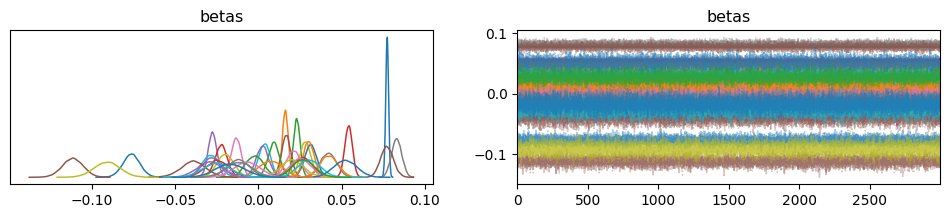

In [ ]:
# Fit the model to get beta estimates
trace_mid = fit_dirichlet_regression(X_mid_pca, mid_probs)

# Extract the mean of the beta posterior samples to use in Algorithm 1
beta_estimates_mid = trace_mid.posterior['betas'].mean(axis=(0,1)).values

trace_mid
az.plot_trace(trace_mid, combined=True)

Fitting Dirichlet regression model with PyMC...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [betas]


Output()

Output()

Output()

Output()

Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 137 seconds.


✅ Model fitting complete.


array([[<Axes: title={'center': 'betas'}>,
        <Axes: title={'center': 'betas'}>]], dtype=object)

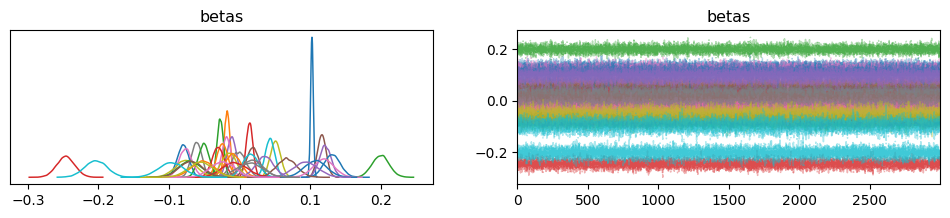

In [39]:
# Fit the model to get beta estimates
trace_fwd = fit_dirichlet_regression(X_fwd_pca, fwd_probs)

# Extract the mean of the beta posterior samples to use in Algorithm 1
beta_estimates_fwd = trace_fwd.posterior['betas'].mean(axis=(0,1)).values

trace_fwd
az.plot_trace(trace_fwd, combined=True)

In [40]:
 # Convert to pandas DataFrame
pd.DataFrame({
    "gk": beta_estimates_gk
}).to_csv('./gk_beta_1.csv', index=False)

pd.DataFrame({
    "def": beta_estimates_def
}).to_csv('./def_beta_1.csv', index=False)

pd.DataFrame({
    "mid": beta_estimates_mid
}).to_csv('./mid_beta_1.csv', index=False)

pd.DataFrame({
    "fwd": beta_estimates_fwd
}).to_csv('./fwd_beta_1.csv', index=False)

## Use betas


## Simulate selection probs


In [41]:
def simulate_observed_probs(X: pd.DataFrame):
    X = X.fillna(0)
    np.random.seed(42)
    num_features = X.shape[1]
    true_beta = np.random.uniform(-0.5, 0.5, size=(num_features,))
    logits = X @ true_beta
    probs = np.exp(logits)
    probs /= probs.sum()
    return probs

# simulate_observed_probs(X_gk_pca)

### Get betas


In [42]:
def dirichlet_regression_beta_auto(data: pd.DataFrame):
    """
    Perform Bayesian Dirichlet Regression.
    If no observed_probs are given, simulate them based on features.
    """
    if not isinstance(data, pd.DataFrame):
        raise ValueError("Data must be a pandas DataFrame.")

    if data.isnull().any().any():
        raise ValueError("Data contains NaN values. Please clean it first.")

    num_players, num_features = data.shape
    print(f"Number of Players: {num_players}, Number of Features: {num_features}")

    X = data.to_numpy(dtype=np.float64)
    # X = X.fillna(0)

    # --- Simulate observed probabilities ---
    observed_probs = simulate_observed_probs(data)

    with pm.Model() as model:
        # Wide normal prior
        beta = pm.Normal("beta", mu=0, sigma=10, shape=(num_features,))

        eta = pm.math.dot(X, beta)
        alpha = pm.math.exp(eta)

        pm.Dirichlet("obs", a=alpha, observed=observed_probs)

        trace = pm.sample(
            draws=2000,
            # tune=50,
            target_accept=0.95,
            chains=2,
            cores=2,
            return_inferencedata=True,
            progressbar=True,
            # nuts_sampler="numpyro"
        )

    beta_estimated = trace.posterior["beta"].mean(dim=["chain", "draw"]).values

    print("Estimated β values:\n", beta_estimated)
    return beta_estimated

In [79]:
# Suppose your player data
X_data_gk = X_gk_pca.copy()

# Now fit!
beta_gk = dirichlet_regression_beta_auto(X_gk_pca)
joblib.dump(beta_gk, './beta_gk_')


Number of Players: 633, Number of Features: 38


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [beta]


Output()

Sampling 2 chains for 1_000 tune and 123 draw iterations (2_000 + 246 draws total) took 763 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Estimated β values:
 [-0.11432032  0.44297611  0.19622999  0.05377961 -0.15858212 -0.35316102
 -0.40796625  0.34445483  0.16101467  0.22230122 -0.47317602  0.47555408
  0.35192937 -0.17955711 -0.24126447 -0.27619033 -0.22117641 -0.01995807
  0.01709094 -0.02513788  0.10222214 -0.31507794 -0.17391513 -0.09538896
  0.0336546   0.2574569  -0.22412616  0.01958343  0.04127276 -0.41051149
  0.07499087 -0.31033307 -0.48510604  0.40420531  0.34734459  0.30541489
 -0.17581561 -0.38586219]


['./beta_gk_']

array([[<Axes: title={'center': 'x'}>, <Axes: title={'center': 'x'}>]],
      dtype=object)

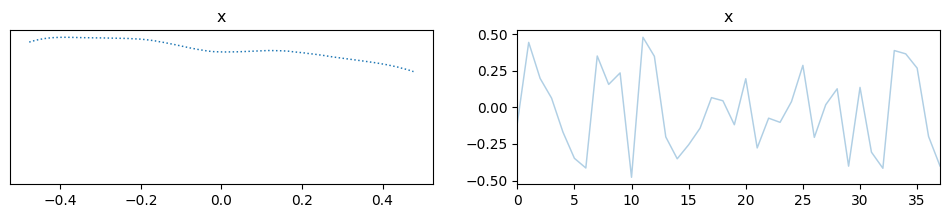

In [ ]:
az.plot_trace(beta_gk, combined=True)


In [ ]:
# Suppose your player data
X_data_def = X_def_pca.copy()

# Now fit!
beta_def = dirichlet_regression_beta_auto(X_data_def)

Number of Players: 2983, Number of Features: 43


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [beta]


Output()

ValueError: Not enough samples to build a trace.

array([[<Axes: title={'center': 'x'}>, <Axes: title={'center': 'x'}>]],
      dtype=object)

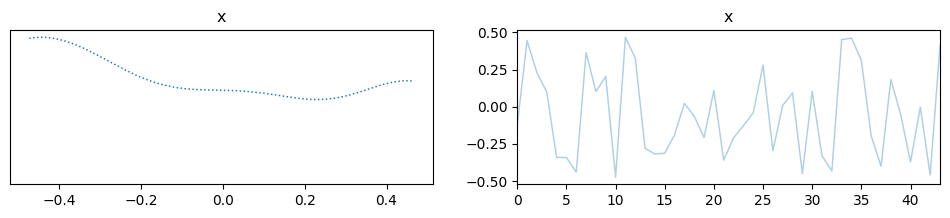

In [ ]:
az.plot_trace(beta_def, combined=True)

In [ ]:
# Suppose your player data
X_data_mid = X_mid_pca.copy()

# Now fit!
beta_mid = dirichlet_regression_beta_auto(X_data_mid)

Number of Players: 3833, Number of Features: 42


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [beta]


Output()

Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 783 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


Estimated β values:
 [-0.12472392  0.44728916  0.22995489  0.09342967 -0.34148407 -0.33585249
 -0.4351277   0.35302837  0.10251669  0.26132003 -0.43147971  0.43509144
  0.35327643 -0.30584118 -0.30817421 -0.3073109  -0.19386005  0.01316217
 -0.05848379 -0.20343353  0.10423018 -0.36342851 -0.21164614 -0.12801873
 -0.0364032   0.30852497 -0.27219313  0.00223789  0.14843715 -0.36505783
  0.05916226 -0.29329511 -0.42823495  0.48339923  0.48365585  0.31127292
 -0.18585308 -0.38473823  0.17176367 -0.06668807 -0.38393617 -0.00469608]


array([[<Axes: title={'center': 'x'}>, <Axes: title={'center': 'x'}>]],
      dtype=object)

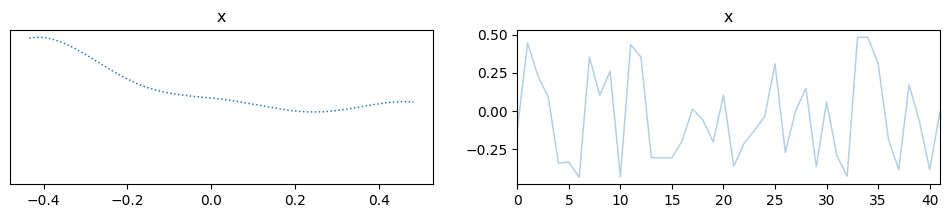

In [ ]:
az.plot_trace(beta_mid, combined=True)

In [ ]:
# Suppose your player data
X_data_fwd = X_fwd_pca.copy()
X_data_fwd = X_data_fwd.fillna(0)

# Now fit!
beta_fwd = dirichlet_regression_beta_auto(X_data_fwd)


Number of Players: 868, Number of Features: 39


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [beta]


Output()

Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 623 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


Estimated β values:
 [-0.11409275  0.43174222  0.20118641  0.09477702 -0.32909269 -0.32615687
 -0.44236097  0.36201924  0.09499141  0.19767085 -0.47432569  0.45613461
  0.31604514 -0.29414627 -0.28035819 -0.3021387  -0.16146517  0.02413207
 -0.05601179 -0.16827096  0.13671569 -0.30595198 -0.1947266  -0.13951951
 -0.05744549  0.27677033 -0.29141072  0.02896625  0.08151839 -0.45640369
  0.0872957  -0.34196812 -0.44960295  0.44251993  0.45808087  0.3028594
 -0.19633513 -0.39434214  0.20709376]


array([[<Axes: title={'center': 'x'}>, <Axes: title={'center': 'x'}>]],
      dtype=object)

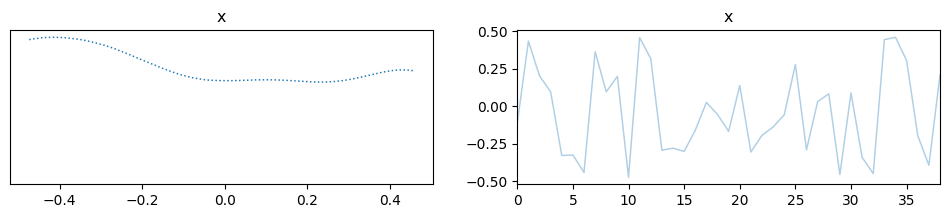

In [ ]:
az.plot_trace(beta_fwd, combined=True)

In [ ]:
 # Convert to pandas DataFrame
pd.DataFrame({
    "gk": beta_gk
}).to_csv('./gk_beta.csv', index=False)

pd.DataFrame({
    "def": beta_def
}).to_csv('./def_beta.csv', index=False)

pd.DataFrame({
    "mid": beta_mid
}).to_csv('./mid_beta.csv', index=False)

pd.DataFrame({
    "fwd": beta_fwd
}).to_csv('./fwd_beta.csv', index=False)